# 06 - Final Test Set Evaluation

**This is the one and only time the test set is opened.** Everything up to this point, all model comparisons, all tuning, all threshold selection, has used train and validation only. This notebook applies the final chosen model and threshold to `model_ready_test.csv` exactly once, and reports the result honestly, whatever it is.


## 0. Leakage audit confirmation, before opening test data

A final sanity check against `docs/data_dictionary.md`, confirming no post-outcome field made it into the feature set, before test data is touched.


In [1]:
import pandas as pd
from pathlib import Path

test_df = pd.read_csv(Path('../../../data/processed/model_ready_test.csv'))

leakage_fields = ['Delivery Status', 'Days for shipping (real)', 'shipping date (DateOrders)']
present_leakage_fields = [c for c in leakage_fields if c in test_df.columns]

assert len(present_leakage_fields) == 0, f"Leakage fields found in feature set: {present_leakage_fields}"
print("Leakage audit passed — no post-outcome fields present in the feature set.")
print(f"Test set shape: {test_df.shape}")


Leakage audit passed — no post-outcome fields present in the feature set.
Test set shape: (11836, 29)


## 1. Load the final chosen model and threshold

In [2]:
import joblib
import json

# Final model: tuned Random Forest (best validation Recall among the tuned candidates)
final_model = joblib.load('../../../models/random_forest_tuned.pkl')

with open('../../../data/processed/chosen_threshold.json') as f:
    threshold_info = json.load(f)
CHOSEN_THRESHOLD = threshold_info['threshold']
print(f"Using threshold: {CHOSEN_THRESHOLD}")

bool_cols = test_df.select_dtypes(include='bool').columns
test_df[bool_cols] = test_df[bool_cols].astype(int)

X_test = test_df.drop(columns=['Late_delivery_risk'])
y_test = test_df['Late_delivery_risk']


Using threshold: 0.38


## 2. Evaluate on the test set, at both the default and the chosen threshold

In [3]:
from sklearn.metrics import (recall_score, precision_score, f1_score, roc_auc_score,
                              average_precision_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

y_score_test = final_model.predict_proba(X_test)[:, 1]

for label, thresh in [('Default (0.5)', 0.5), (f'Chosen ({CHOSEN_THRESHOLD:.2f})', CHOSEN_THRESHOLD)]:
    y_pred_test = (y_score_test >= thresh).astype(int)
    print(f"--- {label} ---")
    print(f"Recall: {recall_score(y_test, y_pred_test):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_test):.4f}")
    print(f"F1: {f1_score(y_test, y_pred_test):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_score_test):.4f}")
    print(f"PR-AUC: {average_precision_score(y_test, y_score_test):.4f}")
    print()


--- Default (0.5) ---
Recall: 0.6522
Precision: 0.7314
F1: 0.6895
ROC-AUC: 0.7515
PR-AUC: 0.8227

--- Chosen (0.38) ---
Recall: 0.8823
Precision: 0.6061
F1: 0.7186
ROC-AUC: 0.7515
PR-AUC: 0.8227



**What we found:** the model generalizes reasonably well, with a small drop in ranking quality, but the chosen threshold does not carry over exactly. The test set has 11,836 orders, 55.1% of them late (validation: 54.2%).

| Metric | Validation, 0.5 | Test, 0.5 | Validation, 0.38 | Test, 0.38 |
|---|---|---|---|---|
| Recall | 0.629 | 0.652 | 0.814 | **0.882** |
| Precision | 0.775 | 0.731 | 0.633 | **0.606** |
| ROC-AUC | 0.762 | 0.752 | 0.762 | 0.752 |
| PR-AUC | 0.827 | 0.823 | 0.827 | 0.823 |

- **Ranking quality held up, with a small drop.** ROC-AUC fell by about 0.01 (0.762 to 0.752) and PR-AUC by about 0.004. ROC-AUC and PR-AUC do not depend on the threshold, so these are the fairest validation-to-test comparison. A drop this small suggests the selection effects from tuning on the validation set were minor.
- **Precision fell at both thresholds** (0.775 to 0.731 at 0.5; 0.633 to 0.606 at 0.38), which matches the slightly weaker ranking.
- **The higher test Recall at 0.38 (0.882 vs 0.814) is not an improvement in the model.** The model gave higher risk scores to test orders overall, so more of them crossed the threshold: **80% of test orders are flagged, against 70% on validation.** More orders flagged means more late orders caught, but also more false alarms. Treat 0.88 as the result of flagging more orders, not as a sign that the model got better on new data. We have not investigated why scores shifted upward on the most recent orders; a small shift in the late rate (55.1% vs 54.2%) is not enough to explain it.
- **Takeaway:** a fixed threshold chosen on validation does not give the same workload on later data. If the app uses a threshold, plan to re-check how many orders it flags as new data arrives.

## 3. Full evaluation visuals at the chosen threshold

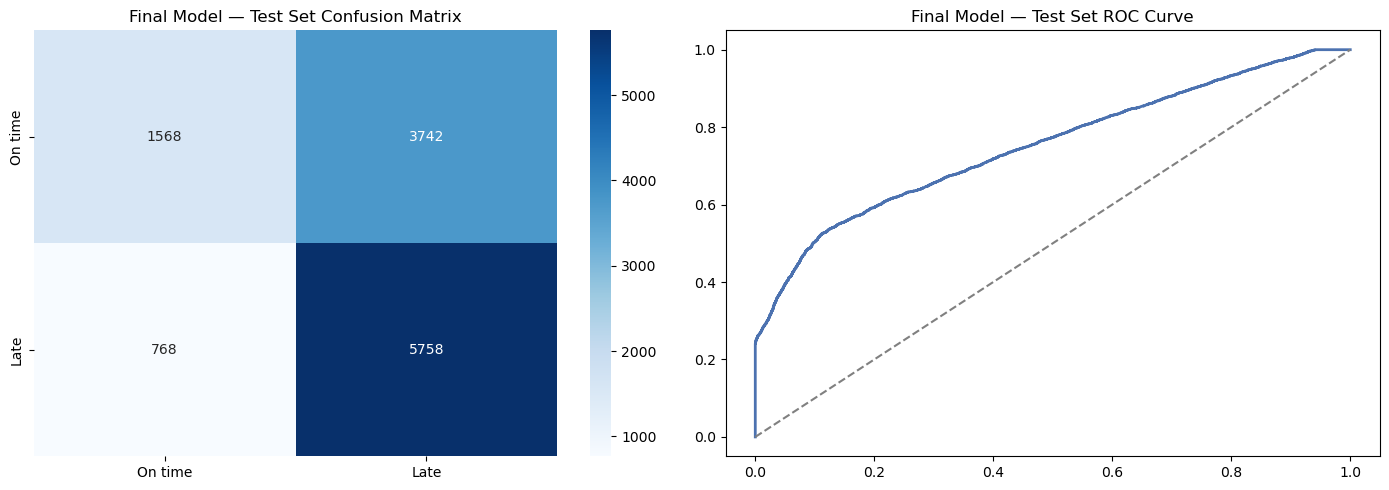

              precision    recall  f1-score   support

 On time (0)       0.67      0.30      0.41      5310
    Late (1)       0.61      0.88      0.72      6526

    accuracy                           0.62     11836
   macro avg       0.64      0.59      0.56     11836
weighted avg       0.64      0.62      0.58     11836



In [4]:
y_pred_final = (y_score_test >= CHOSEN_THRESHOLD).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['On time', 'Late'], yticklabels=['On time', 'Late'])
axes[0].set_title('Final Model — Test Set Confusion Matrix')

from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_score_test)
axes[1].plot(fpr, tpr, color='#4C72B0', linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('Final Model — Test Set ROC Curve')

plt.tight_layout()
plt.savefig('../../../reports/figures/final_test_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred_final, target_names=['On time (0)', 'Late (1)']))


In [ ]:
import numpy as np

order = np.argsort(-y_score_test, kind='stable')
y_sorted = np.asarray(y_test)[order]
rows = []
for k in [0.05, 0.10, 0.20, 0.30]:
    n = int(len(y_sorted) * k)
    top = y_sorted[:n]
    rows.append({'ops can act on': f"top {k:.0%} ({n} orders)",
                 'share that are truly late': round(top.mean(), 3),
                 'share of all late orders caught': round(top.sum() / y_sorted.sum(), 3)})
pd.DataFrame(rows)

,ops can act on,share that are truly late,share of all late orders caught
0,top 5% (591 orders),1.000,0.091
1,top 10% (1183 orders),1.000,0.181
2,top 20% (2367 orders),0.931,0.338
3,top 30% (3550 orders),0.875,0.476


**What we found:** at the chosen threshold of 0.38, the final model catches **5,758 of the 6,526 late orders on the test set (88.2% Recall)** and misses 768. To do that it flags **9,500 of 11,836 orders (80%)**, and 3,742 of those flags are false alarms (Precision 60.6%).

In business terms, for every 100 orders: about 80 are flagged, about 49 of those are truly late, about 32 are false alarms, about 13 are correctly left alone, and about 6 late orders are missed.

**The honest reading is that this is a high-Recall, low-selectivity setup.** Only 1,568 of the 5,310 on-time orders (30%) are correctly cleared, so ops would still need to look at most orders. Flagging every order would give Recall 100% and Precision 55.1%, so the model's Precision of 60.6% is only 5.5 points above flagging everything, in exchange for 12 points of Recall. The model adds real value over a blanket "check everything" rule, but a modest amount at this threshold, and about 6% of late orders still go unnoticed.

**The top of the ranking is where the model is strongest** (see the cell above). On the test set the 10% of orders with the highest scores (1,183 orders) are all late, and the top 20% are 93% late. For the shipment prioritization lens, a ranked list of the highest-risk, highest-value orders is a far more selective and useful output than the yes/no flag.

**Recommendation for Stage 9:** present both uses of the model. The threshold gives a broad "watch list" with high Recall, and the ranked top of the list gives a short, high-confidence action queue.

## 4. Save final results

In [5]:
final_results = {
    'model': type(final_model).__name__,
    'threshold': CHOSEN_THRESHOLD,
    'test_recall': float(recall_score(y_test, y_pred_final)),
    'test_precision': float(precision_score(y_test, y_pred_final)),
    'test_f1': float(f1_score(y_test, y_pred_final)),
    'test_roc_auc': float(roc_auc_score(y_test, y_score_test)),
    'test_pr_auc': float(average_precision_score(y_test, y_score_test)),
}
with open('../../../data/processed/final_test_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print("Saved final test results.")
print("\nStage 7/8 complete. Ready for Stage 9: Recommendation.")


Saved final test results.

Stage 7/8 complete. Ready for Stage 9: Recommendation.
